# Stack Overflow Survey Compensation Model

This notebook takes the cleaned respondent baseline built from `src/comp_clean.py`, sets modeling year windows, and fits the potential compensation models with the goal of estimating which factors are most associated with respondents' total compensation.

## Modeling Plan

1. Load `clean_core` from a parquet built from the cleaning notebook
2. Run a stricter country QA on the compensation sample
3. Inflation-adjust annual compensation to 2025 dollars using CPI-U annual averages
4. Compare the candidate modeling windows from the cleaning notebook
5. Fit a year-region median benchmark, then Ridge, ElasticNet, and ExtraTrees on the main window
6. Run later-year side models for the tech-rich and AI-era windows
7. Use permutation importance on the selected core model to see which feature families matter most


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Ignore noisy packages
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Set display parameters to view more and keep easy to view style
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42


# Robust method to make sure we have the correct file paths
def find_root():
    here = Path.cwd()
    for path in [here, *here.parents]:
        if (path / 'data').exists():
            return path
    raise FileNotFoundError("Could not find project root")

ROOT = find_root()
DATA_DIR = ROOT / 'data'
DERIVED_DIR = DATA_DIR / 'derived'
print(ROOT)

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis


## Load Finalized Clean Core

Double checks to make sure the `clean_core.parquet` file exists and that the columns are formatted as expected for the models.

In [2]:
CLEAN_PATH = DERIVED_DIR / 'clean_core.parquet'

if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run `python src/comp_clean.py` first to build data/derived/clean_core.parquet")

clean_core = pd.read_parquet(CLEAN_PATH)
string_cols = clean_core.select_dtypes(include='string').columns
clean_core[string_cols] = clean_core[string_cols].astype(object)
clean_core[string_cols] = clean_core[string_cols].where(pd.notna(clean_core[string_cols]), np.nan)
clean_core['survey_year_str'] = clean_core['survey_year'].astype(str)
role_cols = sorted(col for col in clean_core.columns if col.startswith('role_'))

print(CLEAN_PATH)
print(clean_core.shape)
display(clean_core[['survey_year', 'country_clean', 'region', 'comp_real_2025'] + role_cols[:4]].sample(5, random_state=RANDOM_STATE))

c:\Users\davis\Documents\VCCode Repos\Stack-Overflow-Survey-Analysis\DSBA-6211-Stack-overflow-Survey-Analysis\data\derived\clean_core.parquet
(746226, 84)


,survey_year,country_clean,region,comp_real_2025,role_back_end,role_data_ml,role_desktop_enterprise,role_devops_cloud
660422,2024,Thailand,Asia,NaN,0,0,0,0
115194,2017,New Zealand,Oceania,NaN,0,0,0,0
462718,2021,Denmark,Europe,140320.906639,1,0,1,0
683102,2024,United States,Americas,NaN,1,0,0,0
116754,2017,United States,Americas,NaN,0,0,0,0


## Loaded Data QA

Checks the number of country responses with unmapped cleaned country values and regions per year, displays the unmapped values, and shows salary trend before and after inflation adjustment.

,window,rows,missing_country_clean,missing_region
0,2019+ core,240651,125,125
1,2021+ tech,160783,59,59
2,2023+ AI,84833,28,28


Remaining raw countries with missing country_clean inside the compensation sample


country
Other Country (Not Listed Above)    86
Nomadic                             71
Other (please specify)              13
I prefer not to say                  6
Name: count, dtype: int64

,survey_year,comp_usd_clean,comp_real_2025
0,2019,56376.0,70993.00
1,2020,54000.0,67172.27
2,2021,55224.0,65612.36
3,2022,66540.0,73199.12
4,2023,75397.0,79663.20
5,2024,67666.0,69446.47
6,2025,80050.0,80050.00


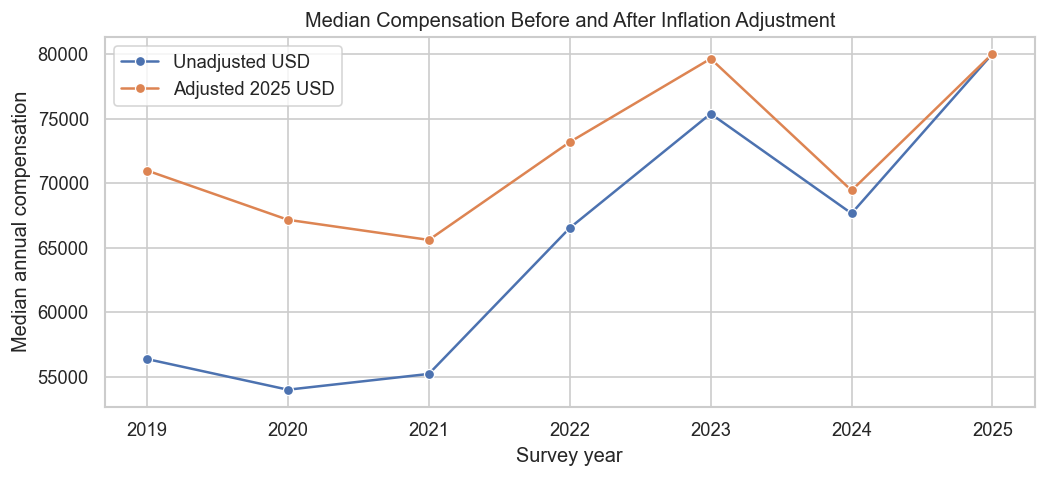

In [4]:
# Builds DataFrame defining windows we intend to use and the missing countries and regions in each
country_qa = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': int(clean_core['is_comp_model_core'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_core'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_core'], 'region'].isna().sum())
    },
    {
        'window': '2021+ tech',
        'rows': int(clean_core['is_comp_model_tech_rich'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_tech_rich'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_tech_rich'], 'region'].isna().sum())
    },
    {
        'window': '2023+ AI',
        'rows': int(clean_core['is_comp_model_ai_era'].sum()),
        'missing_country_clean': int(clean_core.loc[clean_core['is_comp_model_ai_era'], 'country_clean'].isna().sum()),
        'missing_region': int(clean_core.loc[clean_core['is_comp_model_ai_era'], 'region'].isna().sum())
    }
])
display(country_qa)

print("Remaining raw countries with missing country_clean inside the compensation sample")
display(clean_core.loc[clean_core['is_comp_analysis_sample'] & clean_core['country_clean'].isna(), 'country'].value_counts().head(15))

# Median compensation per year, before and after inflation adjustment
median_comp = clean_core.loc[clean_core['is_comp_model_core']].groupby('survey_year')[['comp_usd_clean', 'comp_real_2025']].median().reset_index()
display(median_comp.round(2))

# Trendlines for compensation
plt.figure(figsize=(10, 4))
sns.lineplot(data=median_comp, x='survey_year', y='comp_usd_clean', marker='o', label='Unadjusted USD')
sns.lineplot(data=median_comp, x='survey_year', y='comp_real_2025', marker='o', label='Adjusted 2025 USD')
plt.title("Median Compensation Before and After Inflation Adjustment")
plt.xlabel("Survey year")
plt.ylabel("Median annual compensation")
plt.legend()
plt.show()

## Final Window Choice

The main model should use the window that covers the most years and has reasonable feature coverage this will be 2019+. The later windows can still be used as side models to look at changes from including learning channels, remote work, and AI fields. Since this is temporal data, we'll need to do data splits on time. 2025 will always be the test set, 2024 will be the validation set, and the rest will be the training set. We can't do a more granular split since the responses are just recorded by year, there's no other time separation.

In [5]:
# Define DataFrames for each of the windows we intend to look at (only including rows with region data)
core_df = clean_core[clean_core['is_comp_model_core'] & clean_core['country_clean'].notna()].copy()
tech_df = clean_core[clean_core['is_comp_model_tech_rich'] & clean_core['country_clean'].notna()].copy()
ai_df = clean_core[clean_core['is_comp_model_ai_era'] & clean_core['country_clean'].notna()].copy()

# Show how many rows we have per window as well as the coverage of major features
window_summary = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': len(core_df),
        'train_years': '2019-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(core_df['age_mid'].notna().mean(), 3),
        'experience_share': round(core_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(core_df['country_clean'].notna().mean(), 3),
        'remote_share': round(core_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(core_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2021+ tech',
        'rows': len(tech_df),
        'train_years': '2021-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(tech_df['age_mid'].notna().mean(), 3),
        'experience_share': round(tech_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(tech_df['country_clean'].notna().mean(), 3),
        'remote_share': round(tech_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(tech_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2023+ AI',
        'rows': len(ai_df),
        'train_years': '2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(ai_df['age_mid'].notna().mean(), 3),
        'experience_share': round(ai_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(ai_df['country_clean'].notna().mean(), 3),
        'remote_share': round(ai_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(ai_df['ai_sent'].notna().mean(), 3)
    }
])
display(window_summary)

print("Main compensation window: 2019+ core")
print("Side windows: 2021+ tech and 2023+ AI")

,window,rows,train_years,valid_year,test_year,age_share,experience_share,country_share,remote_share,ai_sent_share
0,2019+ core,240526,2019-2023,2024,2025,0.976,0.991,1.0,0.680,0.273
1,2021+ tech,160724,2021-2023,2024,2025,0.998,0.992,1.0,0.726,0.408
2,2023+ AI,84805,2023,2024,2025,0.999,0.994,1.0,0.977,0.773


Main compensation window: 2019+ core
Side windows: 2021+ tech and 2023+ AI


## Feature Sets And Helpers

The core model uses geography, employment, education, organization size, experience, role family, and tech knowledge counts. The side models add fields that only surface in later survey years.


In [6]:
# Categorical and numeric fields for the core model
CORE_CAT = ['survey_year_str', 'region', 'country_clean', 'employment_group', 'education_clean', 'org_size_clean']
CORE_NUM = ['age_mid', 'professional_experience_years', 'language_count', 'database_count', 'platform_count'] + role_cols

# Categorical and numeric fields for the core model
TECH_CAT = CORE_CAT.copy()
TECH_NUM = CORE_NUM + ['learn_code_count', 'webframe_count', 'misc_tech_count']

# Categorical and numeric fields for the core model
AI_CAT = CORE_CAT + ['remote_group', 'ai_use', 'ai_sent']
AI_NUM = TECH_NUM + ['learn_code_online_count', 'coding_activities_count', 'op_sys_prof_count']

TARGET_COL = 'log_comp_real_2025'



# Split data into train, validation, and test sets based on ranges we defined earlier
def split_years(frame, train_years, valid_year, test_year):
    train = frame[frame['survey_year'].isin(train_years)].copy()
    valid = frame[frame['survey_year'] == valid_year].copy()
    test = frame[frame['survey_year'] == test_year].copy()
    return train, valid, test


# Performs full round of evaluation metrics on given model outputs
def score_predictions(y_true_log, pred_log):
    y_true_real = np.exp(y_true_log)
    pred_real = np.exp(pred_log)
    return {
        'medae_real': median_absolute_error(y_true_real, pred_real),
        'mae_real': mean_absolute_error(y_true_real, pred_real),
        'rmse_real': np.sqrt(mean_squared_error(y_true_real, pred_real)),
        'rmse_log': np.sqrt(mean_squared_error(y_true_log, pred_log)),
        'r2_log': r2_score(y_true_log, pred_log)
    }


# Pipeline for linear model. Fits prep imputation, encoding, and scaling to training data and applies it to val/test data
def build_linear_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=500))
        ]), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_cols)
    ])
    return Pipeline([
        ('prep', prep),
        ('model', Ridge())
    ])


# Pipeline for tree model. Fits prep imputation, encoding, and scaling to training data and applies it to val/test data
def build_tree_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1))
        ]), cat_cols),
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median'))
        ]), num_cols)
    ])
    return Pipeline([
        ('prep', prep),
        ('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1))
    ])


# Takes all passed values needed to create, fit, and evaluate each model
def search_and_test(name, pipe, param_grid, train_df, valid_df, test_df, feature_cols):
    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COL]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[TARGET_COL]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL]

    trials = []
    best_params = None
    best_valid = None

    for params in param_grid:
        est = clone(pipe)
        est.set_params(**params)
        est.fit(X_train, y_train)
        valid_metrics = score_predictions(y_valid, est.predict(X_valid))

        row = {'model': name, **params, **{f'valid_{k}': v for k, v in valid_metrics.items()}}
        trials.append(row)

        if best_valid is None or valid_metrics['medae_real'] < best_valid['medae_real']:
            best_valid = valid_metrics
            best_params = params

    final_est = clone(pipe)
    final_est.set_params(**best_params)
    X_train_valid = pd.concat([X_train, X_valid], axis=0)
    y_train_valid = pd.concat([y_train, y_valid], axis=0)
    final_est.fit(X_train_valid, y_train_valid)
    test_metrics = score_predictions(y_test, final_est.predict(X_test))

    return pd.DataFrame(trials), final_est, best_params, best_valid, test_metrics


# Method to score the baseline model that our built models will be compared to
def score_year_region_benchmark(train_df, valid_df, test_df):
    year_region = train_df.groupby(['survey_year', 'region'])['comp_real_2025'].median().rename('pred').reset_index()
    year_only = train_df.groupby('survey_year')['comp_real_2025'].median().rename('pred_year').reset_index()
    overall = train_df['comp_real_2025'].median()

    def predict(frame):
        out = frame[['survey_year', 'region']].merge(year_region, on=['survey_year', 'region'], how='left')
        out = out.merge(year_only, on='survey_year', how='left')
        pred_real = out['pred'].fillna(out['pred_year']).fillna(overall)
        return np.log(pred_real)

    valid_metrics = score_predictions(valid_df[TARGET_COL], predict(valid_df))
    test_metrics = score_predictions(test_df[TARGET_COL], predict(test_df))
    return valid_metrics, test_metrics


# Loss function that will be used to score permutation importance, median since financial data is always skewed
def medae_real_loss(estimator, X, y_log):
    pred_log = estimator.predict(X)
    return -median_absolute_error(np.exp(y_log), np.exp(pred_log))

## Benchmark

This is an intentionally simple baseline model that predicts the training set median real compensation for each survey year and region. If a year-region pair is missing, it falls back to the year median and then the overall median.


In [7]:
core_train, core_valid, core_test = split_years(core_df, [2019, 2020, 2021, 2022, 2023], 2024, 2025)

benchmark_valid, benchmark_test = score_year_region_benchmark(core_train, core_valid, core_test)
benchmark_results = pd.DataFrame([{
    'model': 'Year-region median benchmark',
    'valid_medae_real': benchmark_valid['medae_real'],
    'valid_rmse_real': benchmark_valid['rmse_real'],
    'valid_rmse_log': benchmark_valid['rmse_log'],
    'test_medae_real': benchmark_test['medae_real'],
    'test_rmse_real': benchmark_test['rmse_real'],
    'test_rmse_log': benchmark_test['rmse_log']
}])
display(benchmark_results.round(2))

,model,valid_medae_real,valid_rmse_real,valid_rmse_log,test_medae_real,test_rmse_real,test_rmse_log
0,Year-region median benchmark,37817.82,80254.4,1.09,38074.73,88700.37,1.05


## Core Models

These are the first real models on the final main window. The benchmark sets the baseline capability and the linear models check how much the additional fields and model setup improve predictions. ExtraTrees gives a nonlinear comparison without requiring us to pull in new dependencies. I chose ExtraTrees over RandomForest because it adds an additional layer of randomization by choose a random threshold for node split values which makes it computationally faster and works better for how noisy our data is, won't get stuck searching for an optimal value.

**This can take several minutes to run, it does multiple trials of multiple models.**


In [8]:
core_features = CORE_CAT + CORE_NUM

# Linear model using Ridge Regression
ridge_pipe = build_linear_pipe(CORE_CAT, CORE_NUM)
ridge_trials, ridge_model, ridge_params, ridge_valid, ridge_test = search_and_test(
    'Ridge',
    ridge_pipe,
    [
        {'model': Ridge(alpha=1.0)},
        {'model': Ridge(alpha=5.0)},
        {'model': Ridge(alpha=10.0)},
        {'model': Ridge(alpha=25.0)}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Linear model using Elastic Net regularization
elastic_pipe = build_linear_pipe(CORE_CAT, CORE_NUM)
elastic_trials, elastic_model, elastic_params, elastic_valid, elastic_test = search_and_test(
    'ElasticNet',
    elastic_pipe,
    [
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.005, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)},
        {'model': ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=5000, random_state=RANDOM_STATE)}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Nonlinear model using the ExtraTreesRegressor
extra_pipe = build_tree_pipe(CORE_CAT, CORE_NUM)
extra_trials, extra_model, extra_params, extra_valid, extra_test = search_and_test(
    'ExtraTrees',
    extra_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 1},
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
    ],
    core_train,
    core_valid,
    core_test,
    core_features
)

# Show the results for each parameter set of each model
print("Linear Ridge model trials:")
display(ridge_trials.round(2))
print("\nLinear Elastic Net model trials:")
display(elastic_trials.round(2))
print("\nNonlinear ExtraTrees model trials:")
display(extra_trials.round(2))


# All four model's results, sorted by lowest validation median absolute error
core_results = pd.DataFrame(
    [
        {
            'model': 'Year-region median benchmark',
            'valid_medae_real': benchmark_valid['medae_real'],
            'valid_rmse_real': benchmark_valid['rmse_real'],
            'test_medae_real': benchmark_test['medae_real'],
            'test_rmse_real': benchmark_test['rmse_real'],
            'test_r2_log': benchmark_test['r2_log']
        },
        {
            'model': 'Ridge',
            'valid_medae_real': ridge_valid['medae_real'],
            'valid_rmse_real': ridge_valid['rmse_real'],
            'test_medae_real': ridge_test['medae_real'],
            'test_rmse_real': ridge_test['rmse_real'],
            'test_r2_log': ridge_test['r2_log']
        },
        {
            'model': 'ElasticNet',
            'valid_medae_real': elastic_valid['medae_real'],
            'valid_rmse_real': elastic_valid['rmse_real'],
            'test_medae_real': elastic_test['medae_real'],
            'test_rmse_real': elastic_test['rmse_real'],
            'test_r2_log': elastic_test['r2_log']
        },
        {
            'model': 'ExtraTrees',
            'valid_medae_real': extra_valid['medae_real'],
            'valid_rmse_real': extra_valid['rmse_real'],
            'test_medae_real': extra_test['medae_real'],
            'test_rmse_real': extra_test['rmse_real'],
            'test_r2_log': extra_test['r2_log']
        }
    ]
).sort_values('valid_medae_real')

print("\nEvaluation metrics for top performing trial of each model:")
display(core_results.round(2))

# Get the best performing model based on our evaluation metrics
best_core_model = extra_model if core_results.iloc[0]['model'] == 'ExtraTrees' else ridge_model if core_results.iloc[0]['model'] == 'Ridge' else elastic_model
best_core_name = core_results.iloc[0]['model']
print(f"\nBest performing trial based on median absolute error: {best_core_name}")


Linear Ridge model trials:


,model,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Ridge(),19864.06,34245.48,61911.50,0.74,0.53
1,Ridge(alpha=5.0),19854.37,34239.68,61909.03,0.74,0.53
2,Ridge(alpha=10.0),19845.54,34233.01,61906.41,0.74,0.53
3,Ridge(alpha=25.0),19803.63,34213.83,61899.06,0.74,0.53



Linear Elastic Net model trials:


,model,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,"ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter...",19966.20,34485.35,62058.83,0.74,0.52
1,"ElasticNet(alpha=0.001, max_iter=5000, random_...",19911.33,34405.44,62032.94,0.74,0.52
2,"ElasticNet(alpha=0.005, l1_ratio=0.2, max_iter...",19997.88,34570.71,62429.70,0.76,0.49
3,"ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=...",20479.78,35156.28,63154.49,0.78,0.46



Nonlinear ExtraTrees model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,ExtraTrees,80,NaN,1,22104.28,37031.96,64745.71,0.75,0.51
1,ExtraTrees,80,24.0,5,20619.09,33074.72,58963.38,0.72,0.54



Evaluation metrics for top performing trial of each model:


,model,valid_medae_real,valid_rmse_real,test_medae_real,test_rmse_real,test_r2_log
1,Ridge,19803.63,61899.06,22294.30,72711.22,0.49
2,ElasticNet,19911.33,62032.94,22225.62,70873.40,0.49
3,ExtraTrees,20619.09,58963.38,25276.58,68537.11,0.48
0,Year-region median benchmark,37817.82,80254.40,38074.73,88700.37,-0.01



Best performing trial based on median absolute error: Ridge


## Later Year Side Models

These are not replacements for the main model. They are to check whether newer fields improve prediction once the survey begins to include them more consistently.


In [9]:
# Split tech and AI windows on years the contain them
tech_train, tech_valid, tech_test = split_years(tech_df, [2021, 2022, 2023], 2024, 2025)
ai_train, ai_valid, ai_test = split_years(ai_df, [2023], 2024, 2025)

tech_features = TECH_CAT + TECH_NUM
ai_features = AI_CAT + AI_NUM

# Nonlinear ExtraTrees model of the increased tech tracking window (2021+)
tech_pipe = build_tree_pipe(TECH_CAT, TECH_NUM)
tech_trials, tech_model, tech_params, tech_valid_metrics, tech_test_metrics = search_and_test(
    'Tech-rich ExtraTrees',
    tech_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5},
        {'model__n_estimators': 80, 'model__max_depth': None, 'model__min_samples_leaf': 5}
    ],
    tech_train,
    tech_valid,
    tech_test,
    tech_features
)

# Nonlinear ExtraTrees model of the increased ai tracking window (2023+)
ai_pipe = build_tree_pipe(AI_CAT, AI_NUM)
ai_trials, ai_model, ai_params, ai_valid_metrics, ai_test_metrics = search_and_test(
    'AI-era ExtraTrees',
    ai_pipe,
    [
        {'model__n_estimators': 80, 'model__max_depth': 18, 'model__min_samples_leaf': 5},
        {'model__n_estimators': 80, 'model__max_depth': 24, 'model__min_samples_leaf': 5}
    ],
    ai_train,
    ai_valid,
    ai_test,
    ai_features
)

print("Tech window (2021+) side model trials:")
display(tech_trials.round(2))
print("\nAi window (2023+) side model trials:")
display(ai_trials.round(2))

# Comparison of all evaluation metrics for the two side models
side_results = pd.DataFrame(
    [
        {
            'model': 'Tech-rich ExtraTrees',
            'valid_medae_real': tech_valid_metrics['medae_real'],
            'test_medae_real': tech_test_metrics['medae_real'],
            'test_rmse_real': tech_test_metrics['rmse_real'],
            'test_r2_log': tech_test_metrics['r2_log']
        },
        {
            'model': 'AI-era ExtraTrees',
            'valid_medae_real': ai_valid_metrics['medae_real'],
            'test_medae_real': ai_test_metrics['medae_real'],
            'test_rmse_real': ai_test_metrics['rmse_real'],
            'test_r2_log': ai_test_metrics['r2_log']
        }
    ]
)

print("\nEvaluation metrics for best performing of both side model trials:")
display(side_results.round(2))

Tech window (2021+) side model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,Tech-rich ExtraTrees,80,24.0,5,17991.74,30495.38,56994.43,0.72,0.55
1,Tech-rich ExtraTrees,80,NaN,5,18098.03,30672.28,57109.05,0.72,0.55



Ai window (2023+) side model trials:


,model,model__n_estimators,model__max_depth,model__min_samples_leaf,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,AI-era ExtraTrees,80,18,5,17745.50,30336.47,57532.39,0.71,0.56
1,AI-era ExtraTrees,80,24,5,17546.65,30180.21,57250.78,0.70,0.56



Evaluation metrics for best performing of both side model trials:


,model,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,Tech-rich ExtraTrees,17991.74,23333.85,66304.41,0.48
1,AI-era ExtraTrees,17546.65,21387.45,66941.63,0.50


## What Seems To Matter So Far

Uses permutation importance on the core model and validation set to summarize which features are influencing compensation the most on  a feature-family level.


Top 15 features by permutation importance:


,feature,importance,family
2,country_clean,25620.56,Geography
1,region,4371.66,Geography
7,professional_experience_years,3529.46,Experience and age
5,org_size_clean,1473.18,Organization size
3,employment_group,1437.17,Employment
4,education_clean,834.84,Education
8,language_count,180.11,Tech breadth
18,role_management,178.82,Role family
22,role_student_academic,115.63,Role family
11,role_back_end,81.31,Role family



Top families by permutation importance:


,family,importance
3,Geography,29992.22
2,Experience and age,3517.46
4,Organization size,1473.18
1,Employment,1437.17
0,Education,834.84
5,Role family,466.97
6,Tech breadth,136.53
7,Time,0.00


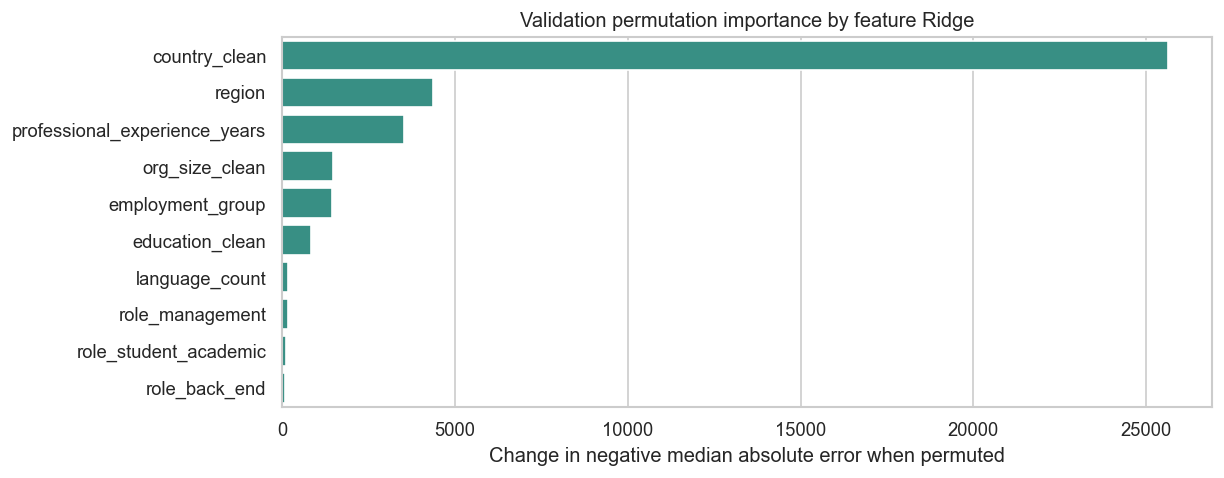

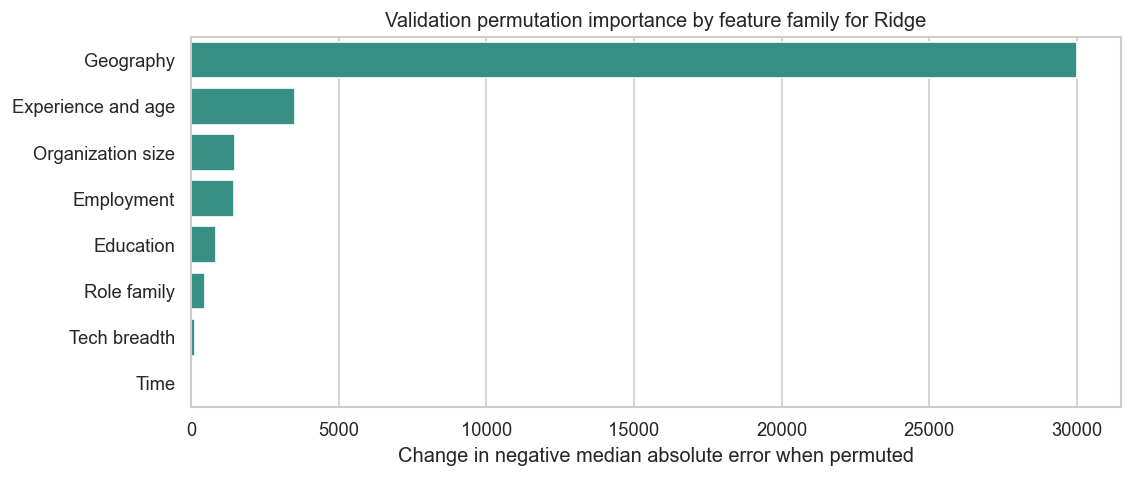

In [10]:
# Groups the features into families of related concepts
family_map = {
    'survey_year_str': 'Time',
    'region': 'Geography',
    'country_clean': 'Geography',
    'employment_group': 'Employment',
    'education_clean': 'Education',
    'org_size_clean': 'Organization size',
    'age_mid': 'Experience and age',
    'professional_experience_years': 'Experience and age',
    'language_count': 'Tech breadth',
    'database_count': 'Tech breadth',
    'platform_count': 'Tech breadth'
}
for col in role_cols:
    family_map[col] = 'Role family'

# Runs permutation importance with validation set using the defined median absolute error loss function
valid_perm = permutation_importance(
    best_core_model,
    core_valid[core_features],
    core_valid[TARGET_COL],
    scoring=medae_real_loss,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

perm_df = pd.DataFrame({
    'feature': core_features,
    'importance': valid_perm.importances_mean,
    'family': [family_map.get(col, 'Other') for col in core_features]
}).sort_values('importance', ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15).round(2))

# Group the features into the respective family and sum their importance values
family_imp = perm_df.groupby('family', as_index=False)['importance'].sum().sort_values('importance', ascending=False)

print("\nTop families by permutation importance:")
display(family_imp.round(2))

# Visualization of the family-level permutation importance
plt.figure(figsize=(10, 4))
sns.barplot(data=perm_df.head(10), x='importance', y='feature', color='#2A9D8F')
plt.title(f"Validation permutation importance by feature {best_core_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()

# Visualization of the family-level permutation importance
plt.figure(figsize=(10, 4))
sns.barplot(data=family_imp, x='importance', y='family', color='#2A9D8F')
plt.title(f"Validation permutation importance by feature family for {best_core_name}")
plt.xlabel("Change in negative median absolute error when permuted")
plt.ylabel("")
plt.show()

## Next Steps

- Add subgroup diagnostics on the 2025 test year by region, role family, and employment type
- Rerun the models using the region grouping alone rather than countries to compare
- Potentially revise the rule used to trim valid compensation values to winsorize value instead
- Test a more tuned tree model against the current Ridge model